Found 5 tar files in /home/anagupta/luna/train_test_split_1/train_cell_images

Processing wildtype_5_7_cell_images.tar:
Found 58685 .npy files in /home/anagupta/luna/train_test_split_1/train_cell_images/wildtype_5_7_cell_images.tar
Selected 3 files: ['imajacja-1.npy', 'bnoidjgd-1.npy', 'kckelkkg-1.npy']
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Plotting 3 images
Image 1 shape: (128, 128)
Image 2 shape: (128, 128)
Image 3 shape: (128, 128)


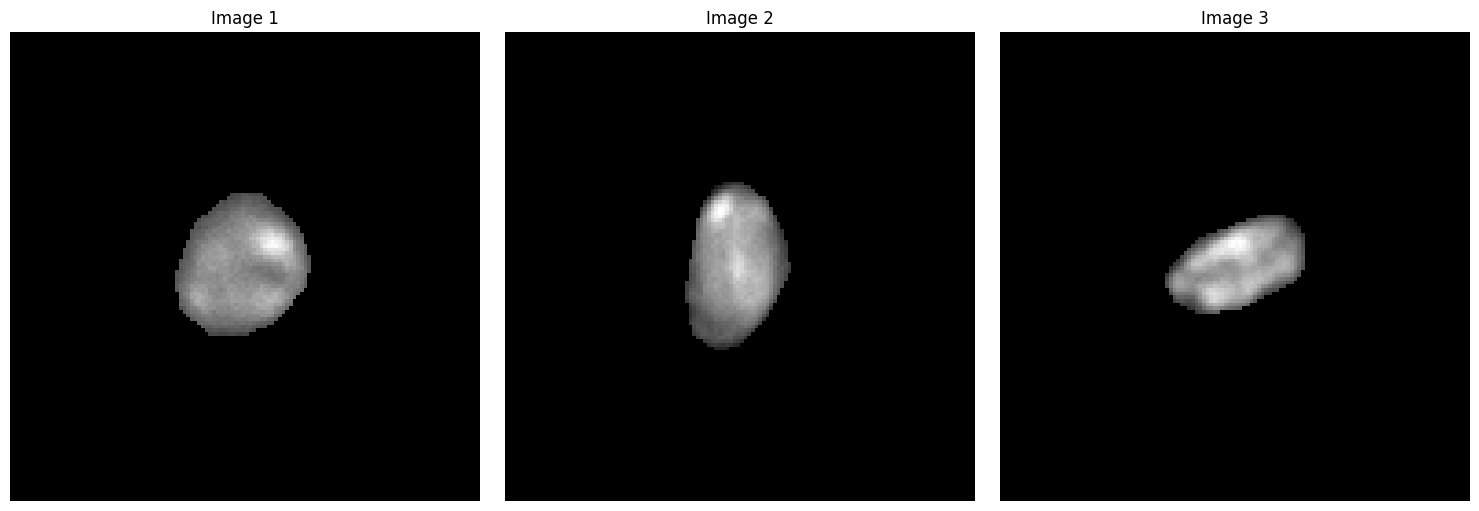


Processing wildtype_2_5_cell_images.tar:
Found 58231 .npy files in /home/anagupta/luna/train_test_split_1/train_cell_images/wildtype_2_5_cell_images.tar
Selected 3 files: ['cocdjaml-1.npy', 'hdljgiop-1.npy', 'icmopaio-1.npy']
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Plotting 3 images
Image 1 shape: (128, 128)
Image 2 shape: (128, 128)
Image 3 shape: (128, 128)


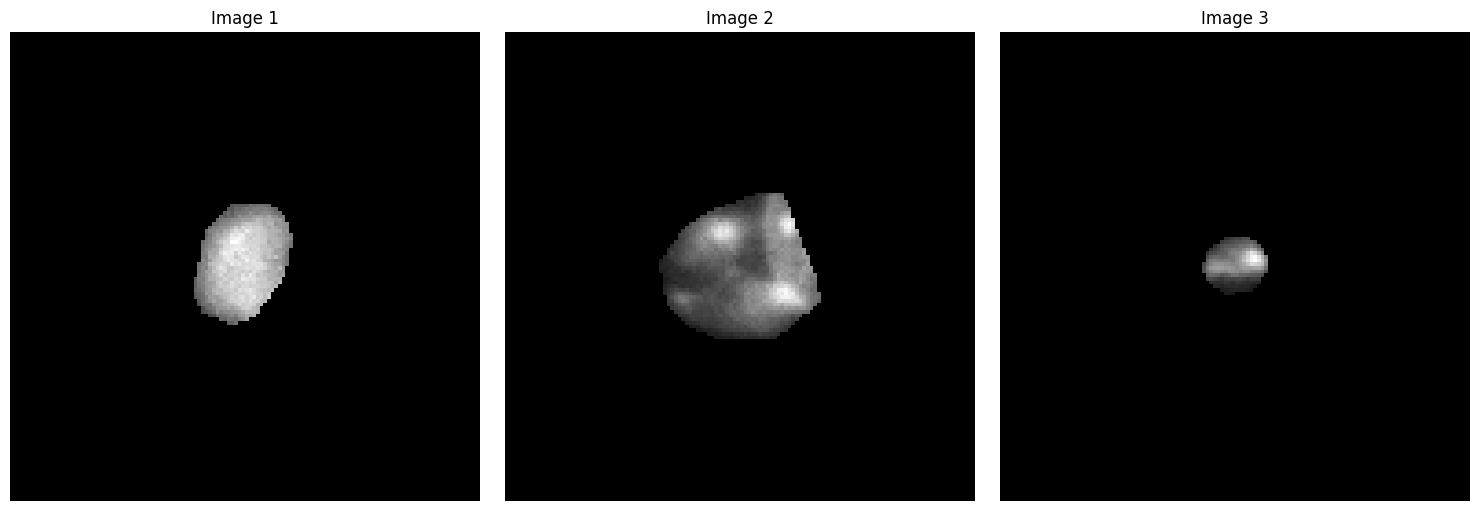


Processing wildtype_13_4_cell_images.tar:
Found 59934 .npy files in /home/anagupta/luna/train_test_split_1/train_cell_images/wildtype_13_4_cell_images.tar
Selected 3 files: ['ibgceffk-1.npy', 'odmmncoj-1.npy', 'kefgegpa-1.npy']
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Plotting 3 images
Image 1 shape: (128, 128)
Image 2 shape: (128, 128)
Image 3 shape: (128, 128)


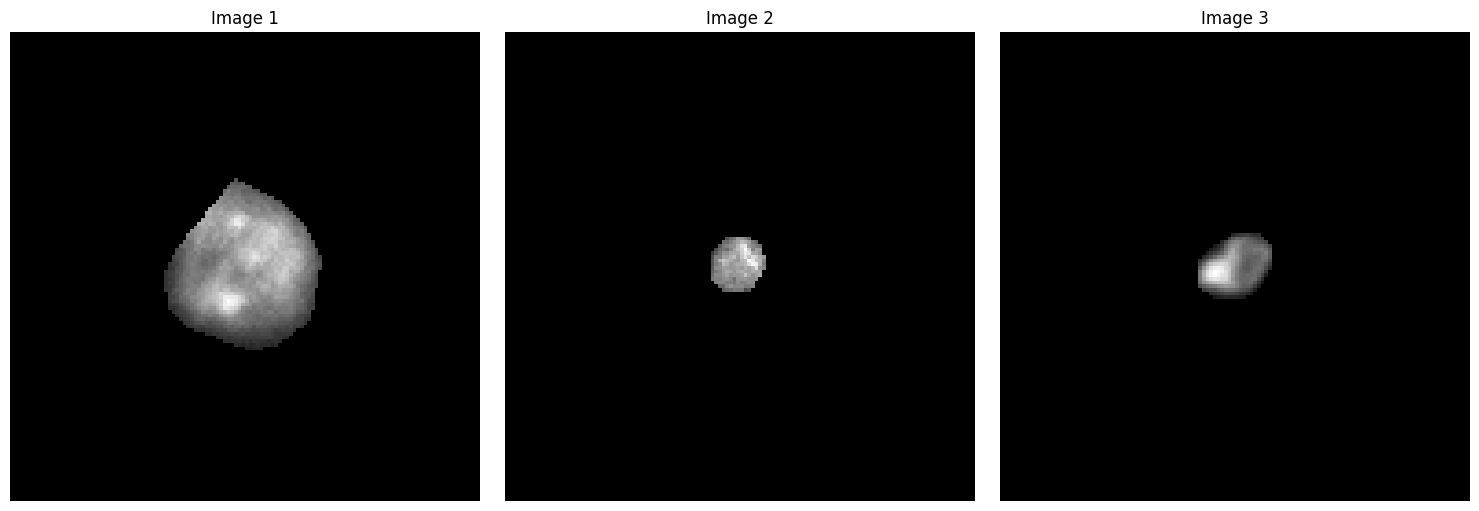


Processing TgCRND8_2_5_cell_images.tar:
Found 53912 .npy files in /home/anagupta/luna/train_test_split_1/train_cell_images/TgCRND8_2_5_cell_images.tar
Selected 3 files: ['dminibnn-1.npy', 'hiiopdee-1.npy', 'ebnajmlh-1.npy']
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Plotting 3 images
Image 1 shape: (128, 128)
Image 2 shape: (128, 128)
Image 3 shape: (128, 128)


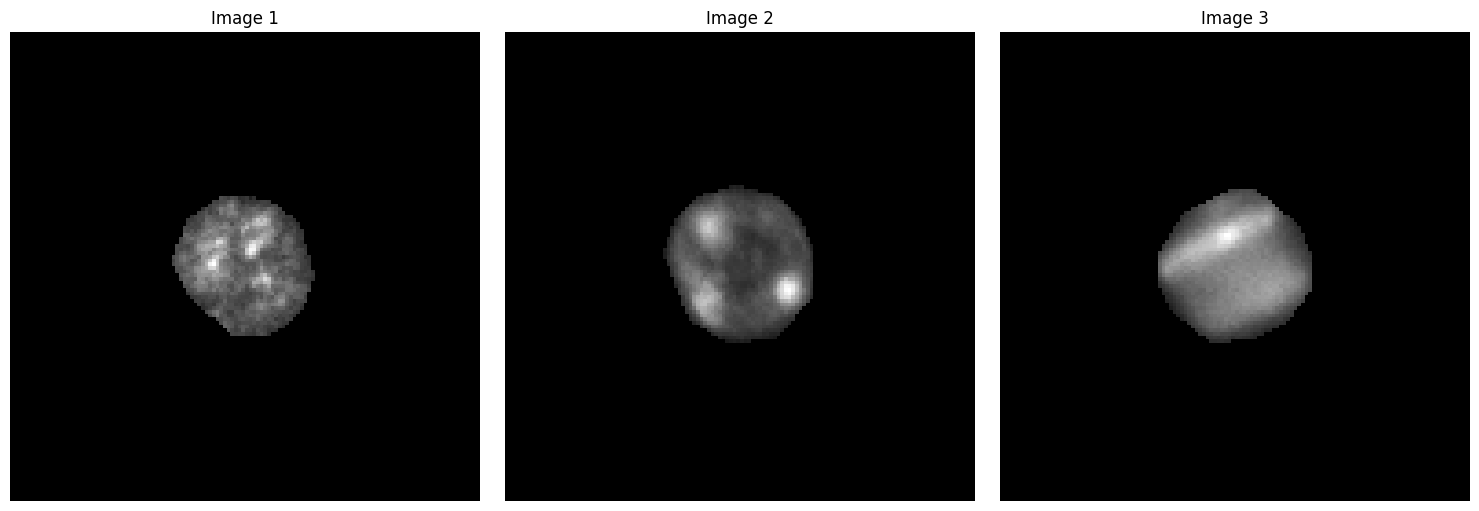


Processing TgCRND8_17_9_cell_images.tar:
Found 62267 .npy files in /home/anagupta/luna/train_test_split_1/train_cell_images/TgCRND8_17_9_cell_images.tar
Selected 3 files: ['daecfnfl-1.npy', 'fmjhhmbl-1.npy', 'lfdnbcdo-1.npy']
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Loaded image shape: (128, 128)
Plotting 3 images
Image 1 shape: (128, 128)
Image 2 shape: (128, 128)
Image 3 shape: (128, 128)


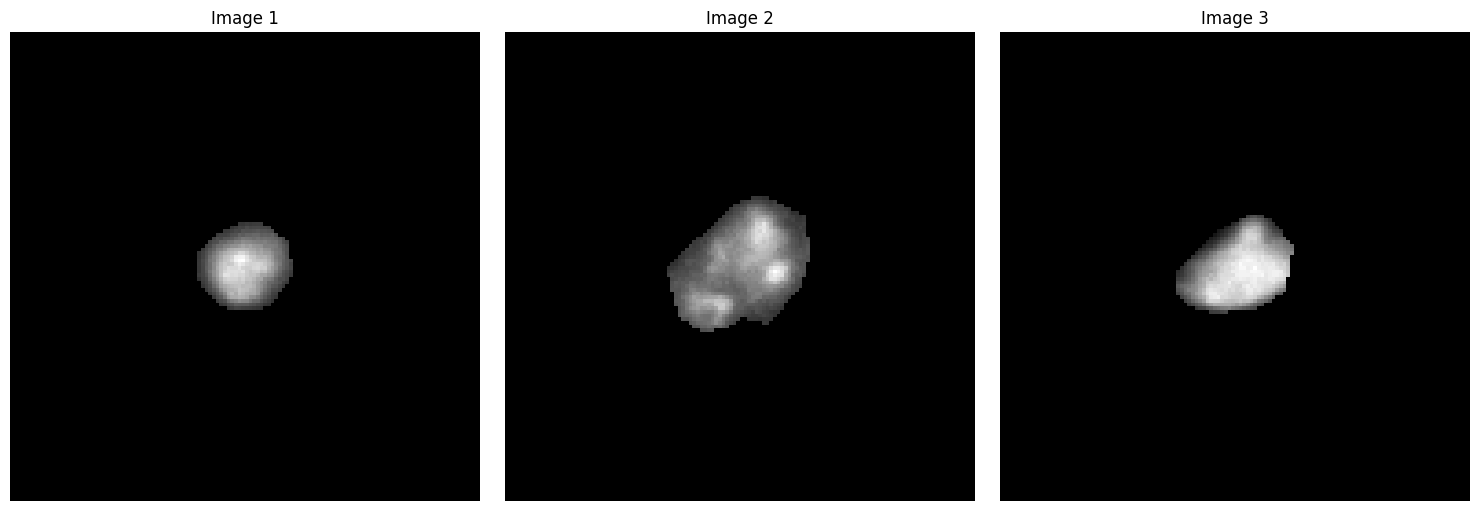

In [1]:
import os
import io
import tarfile  # Changed from zipfile
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

def extract_random_images_from_tar(tar_path, num_images=5):
    """Extract random images from a tar file containing .npy files."""
    images = []
    with tarfile.open(tar_path, 'r') as tar_ref:
        # Get all .npy files in the tar
        npy_files = [f for f in tar_ref.getnames() if f.endswith('.npy')]
        print(f"Found {len(npy_files)} .npy files in {tar_path}")
        if not npy_files:
            return images
        # Randomly select images
        selected_files = random.sample(npy_files, min(num_images, len(npy_files)))
        print(f"Selected {len(selected_files)} files: {selected_files}")
        # Extract and load selected images
        for file in selected_files:
            with tar_ref.extractfile(file) as f:
                # Read the file content into memory
                file_content = f.read()
                # Create a BytesIO object that numpy can read
                img = np.load(io.BytesIO(file_content))
                print(f"Loaded image shape: {img.shape}")
                images.append(img)
    return images

def plot_images(images, titles=None, figsize=(15, 5)):
    """Plot a list of images."""
    n_images = len(images)
    print(f"Plotting {n_images} images")
    fig, axes = plt.subplots(1, n_images, figsize=figsize)
    if n_images == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images)):
        # Ensure image is 2D
        if len(img.shape) > 2:
            img = img.squeeze()
        print(f"Image {i+1} shape: {img.shape}")
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if titles and i < len(titles):
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

# --- USAGE ---

folder_path = '/home/anagupta/luna/train_test_split_1/train_cell_images'
num_images_per_tar = 3  # Changed variable name

tar_files = list(Path(folder_path).glob('*.tar'))  # Changed to .tar
print(f"Found {len(tar_files)} tar files in {folder_path}")

for tar_file in tar_files:
    print(f"\nProcessing {tar_file.name}:")
    images = extract_random_images_from_tar(tar_file, num_images_per_tar)
    if images:
        titles = [f"Image {i+1}" for i in range(len(images))]
        plot_images(images, titles)
    else:
        print("No .npy images found in this tar.")